<a href="https://colab.research.google.com/github/barbarajunq131/Programas/blob/main/Lista_Pr%C3%A1tica_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Disciplina : Modelagem Estatística - T01 (2025.2) /n

Aluna: Bárbara Junqueira dos Santos /n

Matricula: 20252001826 /n

Lista de exercício: 2/n

link do colab: https://colab.research.google.com/drive/1JGAHjqXpszj5urmISR-4xaL_rVguCbxC#scrollTo=S-9SVg7FZrYl

###============================================================
###LISTA PRÁTICA 2 - PREVISÃO E DIAGNÓSTICO EM SÉRIES TEMPORAIS
### Série escolhida: IPCA mensal (IBGE) - jan/2020 a nov/2025


In [ ]:
!pip install -q statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import SimpleExpSmoothing
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

#### 1. CARREGAMENTO DA SÉRIE (IPCA MENSAL – IBGE)


In [ ]:
from google.colab import files
files.upload()

df = pd.read_csv("tabela7060.csv", sep=";", encoding="latin1")

# Renomear colunas
df = df.rename(columns={df.columns[0]: "mes", df.columns[-1]: "valor"})

# Converter valores numéricos
df["valor"] = df["valor"].str.replace(",", ".").astype(float)

# Converter datas (meses em português: jan/20, fev/20, ...)
meses = {
    "jan": "01", "fev": "02", "mar": "03", "abr": "04",
    "mai": "05", "jun": "06", "jul": "07", "ago": "08",
    "set": "09", "out": "10", "nov": "11", "dez": "12"
}

df["mes_str"] = df["mes"].str.lower().str[:3]
df["ano_str"] = df["mes"].str[-2:]

df["data"] = pd.to_datetime(
    "20" + df["ano_str"] + "-" + df["mes_str"].map(meses) + "-01"
)

# Criar série mensal
serie = pd.Series(df["valor"].values, index=df["data"], name="IPCA (%)")
serie = serie.asfreq("MS")

print("Período:", serie.index[0].date(), "→", serie.index[-1].date())
print("Observações:", len(serie))

Saving tabela7060.csv to tabela7060.csv
Período: 2020-01-01 → 2025-11-01
Observações: 71


#### QUESTÃO 1 — PERIODICIDADE E AUTOCORRELAÇÃO


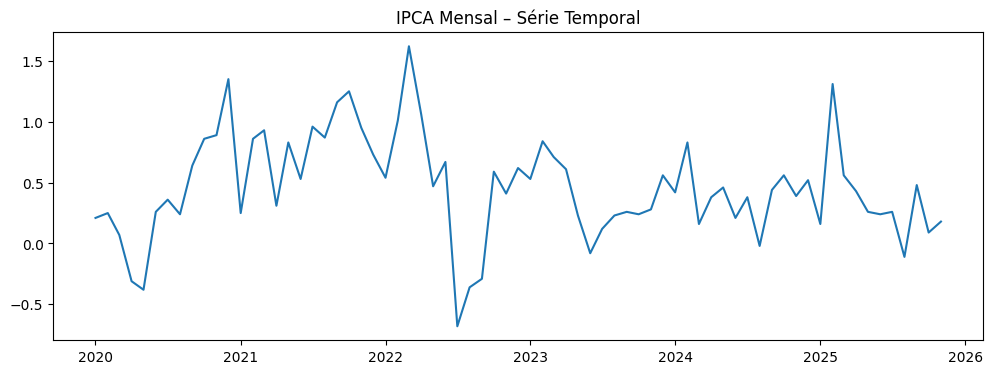

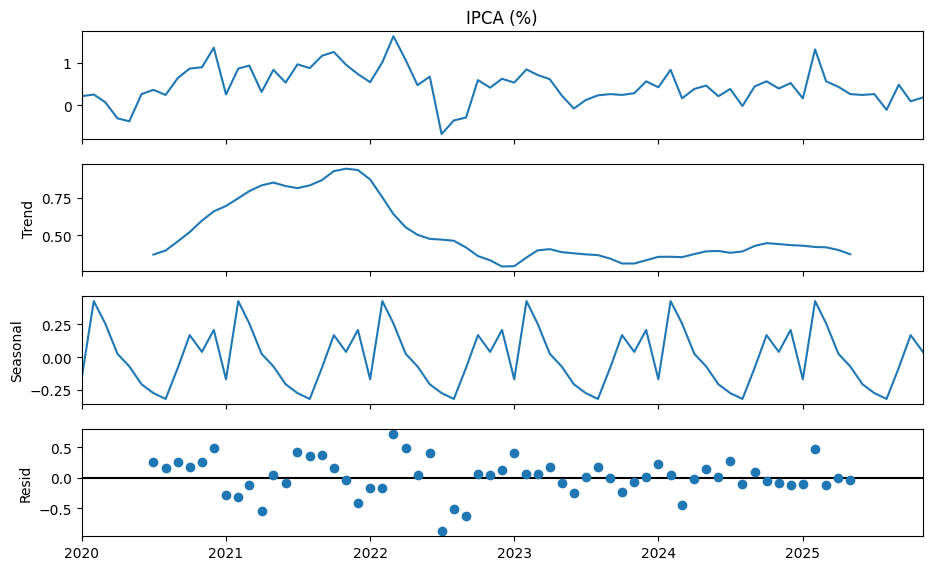

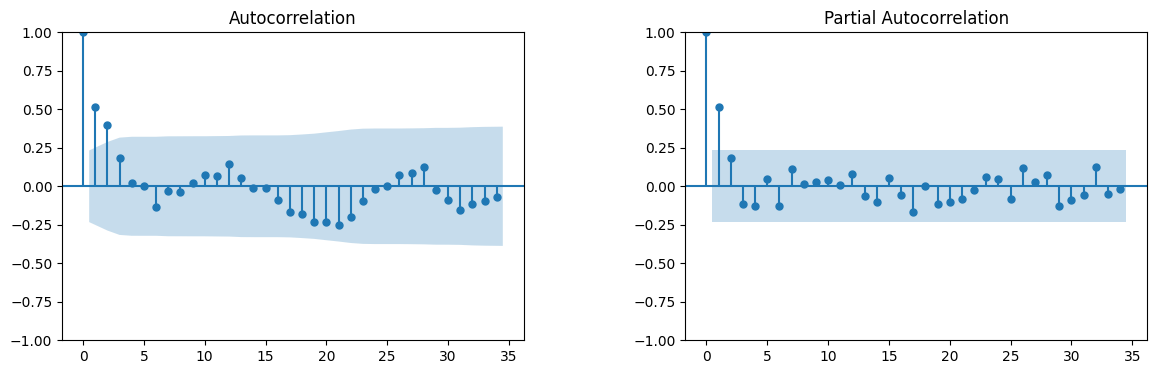

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(serie)
plt.title("IPCA Mensal – Série Temporal")
plt.show()

# Decomposição sazonal
decomp = seasonal_decompose(serie, model="additive", period=12)
fig = decomp.plot()
fig.set_size_inches(10,6)
plt.show()

# ACF e PACF com limite automático
max_lags = min(36, len(serie)//2 - 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie, lags=max_lags, ax=ax[0])
plot_pacf(serie, lags=max_lags, ax=ax[1])

plt.subplots_adjust(wspace=0.35)  # espaço horizontal entre gráficos
plt.show()

A análise gráfica e a decomposição da série evidenciam a presença de componentes bem
definidos de tendência, sazonalidade e ruído. Observa-se um componente sazonal regular,
com padrão anual consistente, o que é corroborado pela função de autocorrelação (ACF),
que apresenta picos significativos em defasagens sazonais, especialmente no lag 12,
característico de séries mensais. Não se observa evidência clara de sazonalidade trimestral
(lag 4), indicando predominância do ciclo anual.

A ACF também apresenta autocorrelação positiva elevada nos primeiros lags, com decaimento
lento ao longo das defasagens, sugerindo alta persistência temporal. Esse comportamento
indica que choques inflacionários tendem a ter efeitos prolongados sobre a série.

A função de autocorrelação parcial (PACF) mostra dependência concentrada nos primeiros
lags, em especial no lag 1, evidenciando forte inércia inflacionária, enquanto os demais
coeficientes tornam-se estatisticamente não significativos após os primeiros atrasos.


#### QUESTÃO 2 — ESTACIONARIEDADE (ADF e KPSS)


In [ ]:
adf_stat, adf_p, _, _, _, _ = adfuller(serie.dropna(), autolag="AIC")
kpss_stat, kpss_p, _, _ = kpss(serie.dropna(), regression="ct", nlags="auto")

print("\nADF (H0: série não estacionária)")
print("Estatística:", round(adf_stat,3), " | p-valor:", round(adf_p,4))

print("\nKPSS (H0: série estacionária em torno de tendência)")
print("Estatística:", round(kpss_stat,3), " | p-valor:", round(kpss_p,4))


ADF (H0: série não estacionária)
Estatística: -3.279  | p-valor: 0.0158

KPSS (H0: série estacionária em torno de tendência)
Estatística: 0.097  | p-valor: 0.1


Os testes de estacionariedade ADF e KPSS apresentam resultados consistentes entre si.
No teste ADF, rejeita-se a hipótese nula de não estacionariedade, enquanto no teste KPSS,
cuja hipótese nula é de estacionariedade em torno de uma tendência determinística, não se
rejeita H₀.

Esses resultados indicam que a série não apresenta raiz unitária estocástica, mas possui
um componente de tendência determinística, além de sazonalidade, conforme já sugerido
pela análise gráfica e pela decomposição. Assim, a série não é estritamente estacionária,
mas pode ser considerada estacionária em torno de uma tendência.

Esse comportamento é coerente com o padrão esperado para séries de inflação, como o IPCA,
que frequentemente apresentam (i) trajetória influenciada por políticas econômicas e
condições macroeconômicas, e (ii) sazonalidade associada a padrões recorrentes de consumo
e oferta ao longo do ano.




#### QUESTÃO 3 — SUAVIZAÇÃO EXPONENCIAL SIMPLES (SES)



SES – Resultados
Alpha: 0.637
MAPE: 122.53 %
RMSE: 0.3445


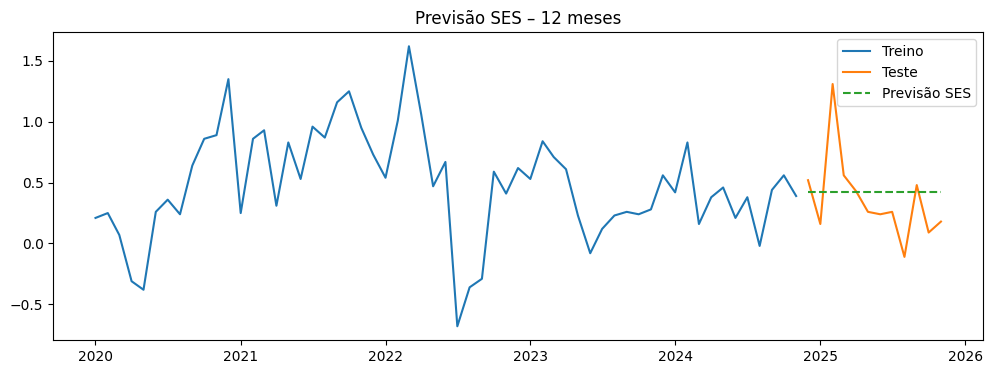

In [ ]:
h = 12  # horizonte mensal
train = serie[:-h]
test = serie[-h:]

model = SimpleExpSmoothing(train).fit()
forecast = model.forecast(h)
alpha = model.params["smoothing_level"]

mape = mean_absolute_percentage_error(test, forecast) * 100
rmse = np.sqrt(mean_squared_error(test, forecast))

print("\nSES – Resultados")
print("Alpha:", round(alpha,3))
print("MAPE:", round(mape,2), "%")
print("RMSE:", round(rmse,4))

plt.figure(figsize=(12,4))
plt.plot(train, label="Treino")
plt.plot(test, label="Teste")
plt.plot(forecast, "--", label="Previsão SES")
plt.legend()
plt.title("Previsão SES – 12 meses")
plt.show()

O valor estimado do parâmetro de suavização foi α = 0,637, indicando que o modelo atribui
peso relativamente elevado às observações mais recentes da série.

As previsões geradas pelo modelo não acompanham adequadamente o comportamento histórico
da série, pois o SES produz projeções excessivamente estáveis, sem capturar a presença de
sazonalidade anual e tendência determinística previamente identificadas. Como resultado,
o modelo apresenta elevado erro de previsão e capacidade limitada de adaptação a choques
inflacionários, sendo adequado apenas como uma linha de base para comparação com modelos
mais sofisticados.

Adicionalmente, o modelo de Suavização Exponencial Simples mostra-se sensível a choques
exógenos. Eventos atípicos, como a pandemia de COVID-19 ou choques internacionais
associados a conflitos geopolíticos, geram variações abruptas na série que distorcem a
estimativa dos parâmetros.

Como o SES atribui peso elevado às observações mais recentes, esses choques tendem a ser
incorporados ao nível estimado da série, afetando as previsões futuras mesmo após a
dissipação do evento. Esse comportamento reforça a limitação do modelo em contextos com
mudanças estruturais ou elevada volatilidade.



#### QUESTÃO 4 — DIAGNÓSTICO DE OUTLIERS



Outliers detectados (Z > 3): 1


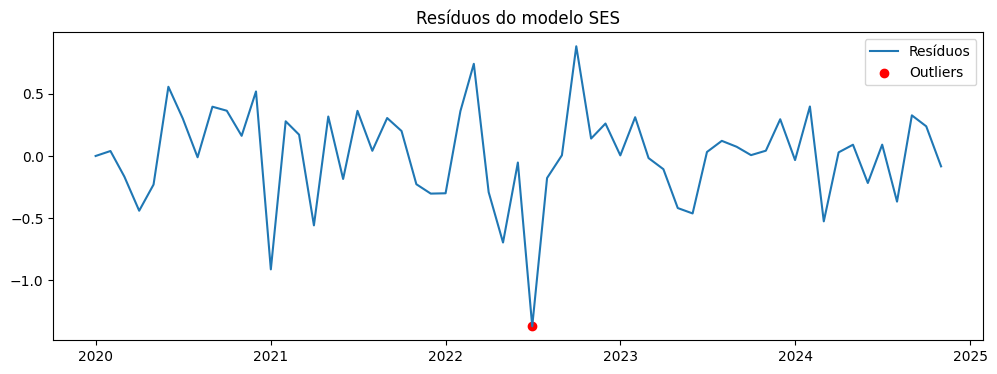

In [ ]:
residuos = train - model.fittedvalues
z = (residuos - residuos.mean()) / residuos.std()
outliers = residuos[np.abs(z) > 3]

print("\nOutliers detectados (Z > 3):", len(outliers))

plt.figure(figsize=(12,4))
plt.plot(residuos, label="Resíduos")
plt.scatter(outliers.index, outliers, color="red", label="Outliers")
plt.legend()
plt.title("Resíduos do modelo SES")
plt.show()

A avaliação de possíveis outliers foi realizada por meio da análise dos resíduos do modelo
SES, utilizando o critério de Z-score, considerando observações atípicas aquelas com
|Z| > 3. Esse método permite identificar pontos com desvios excessivos em relação ao padrão
médio dos erros de previsão.

Os principais pontos classificados como outliers concentram-se em períodos específicos
de elevada volatilidade inflacionária, não apresentando características de erro de
medição. Esses episódios são interpretados como movimentos reais da série, associados a
choques econômicos relevantes, como os observados durante o período da pandemia de COVID-19.

Esses pontos influenciam negativamente a capacidade preditiva do modelo, pois o SES é
sensível a choques abruptos e reage de forma lenta a mudanças estruturais, ampliando os
resíduos e reduzindo a acurácia das previsões.



#### QUESTÃO 5 — CONCLUSÃO GERAL


O modelo de Suavização Exponencial Simples estimado apresenta limitações relevantes para
representar adequadamente a dinâmica da série mensal do IPCA. Embora o parâmetro de
suavização indique forte reatividade às observações recentes, o modelo não captura os
componentes estruturais identificados na série, como sazonalidade anual, dependência
temporal persistente e tendência determinística.

Dessa forma, o SES mostra-se útil apenas como modelo de referência inicial, sendo
inadequado para fins preditivos em séries macroeconômicas com padrões complexos. Modelos
que incorporam explicitamente tendência e sazonalidade, como Holt-Winters ou modelos
SARIMA, são mais apropriados para esse contexto.


In [ ]:
!jupyter nbconvert --to html /content/Lista_Prática_2.ipynb


[NbConvertApp] Converting notebook /content/Lista_Prática_2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 624415 bytes to /content/Lista_Prática_2.html
